# Get Data

In [179]:
from pathlib import Path
import pandas as pd
import numpy as np
import zipfile

def extract_titanic_data():
    """
    Returns two dataframes: train and test
    """
    zip_path = Path("datasets/titanic.zip")
    extract_dir = Path("datasets/titanic")

    if not zip_path.exists():
        print("File not found")

    if not extract_dir.exists():
        extract_dir.mkdir(parents=True, exist_ok=True)
        print(f"Creating {extract_dir}")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
        
    train_data = pd.read_csv(Path(extract_dir) / "train.csv")
    test_data = pd.read_csv(Path(extract_dir) / "test.csv")
    return train_data, test_data

# Load the dataframes
train_df, test_df = extract_titanic_data()

# Display the first few rows of each dataframe
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [180]:
test_df.head()


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [181]:
train_df.info()
print()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass 

array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>, <Axes: >, <Axes: >]],
      dtype=object)

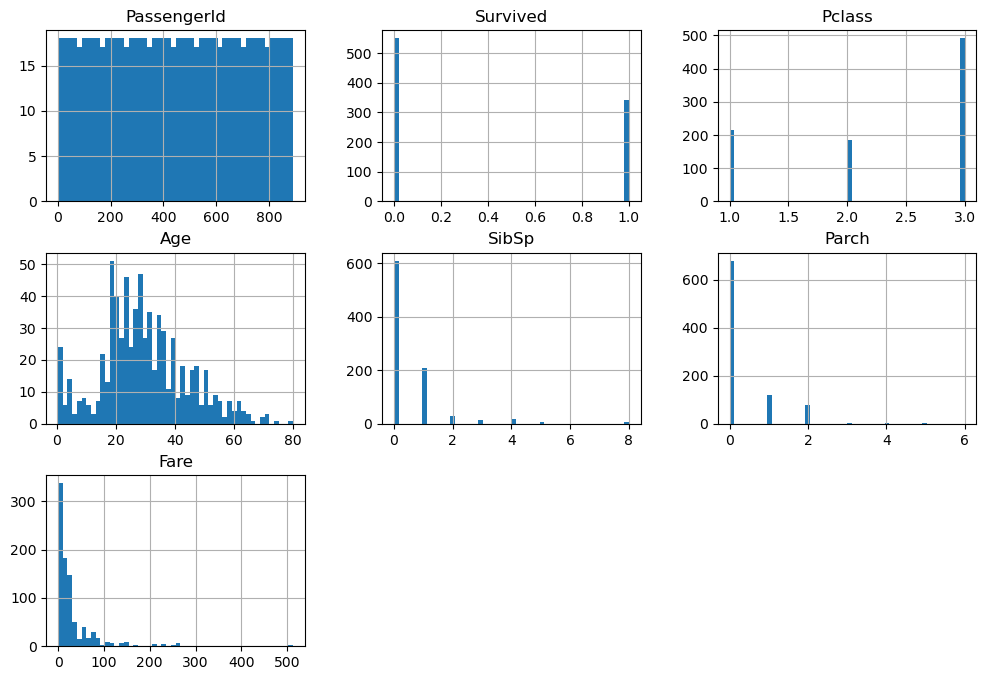

In [182]:
train_df.hist(bins=50, figsize=(12, 8))


In [183]:
corr_matrix = train_df.corr(numeric_only=True)
corr_matrix["Survived"].sort_values(ascending=False)



Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

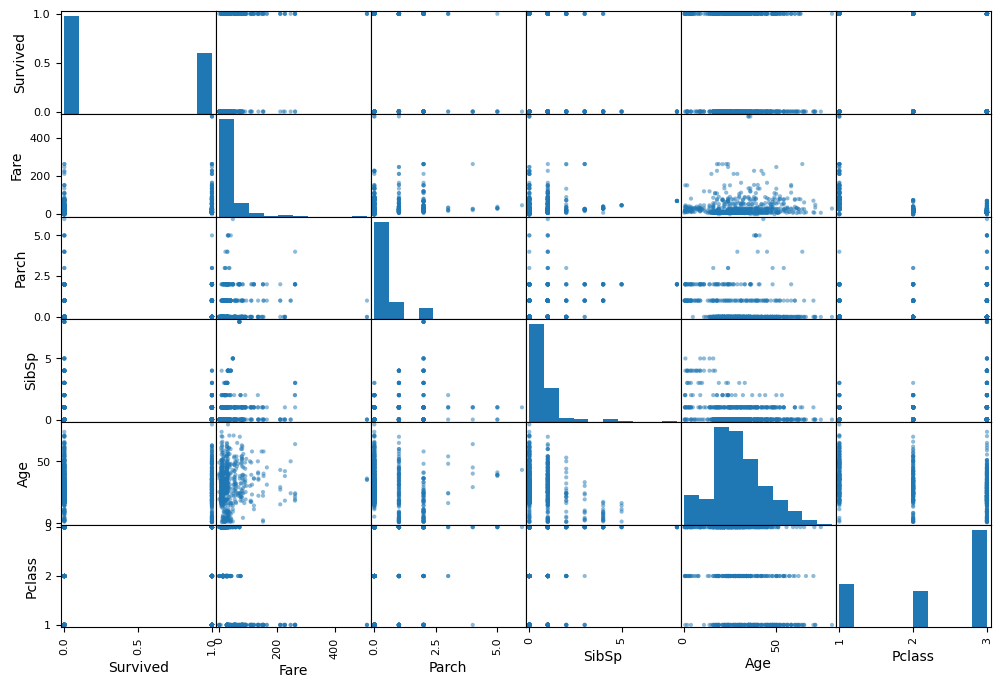

In [184]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

attributes = ["Survived", "Fare", "Parch", "SibSp",
              "Age", "Pclass"]
scatter_matrix(train_df[attributes], figsize=(12, 8))

plt.show()

# Preprocessing

In [185]:
import sklearn

train_features = train_df.drop(columns=['Survived'])
train_labels = train_df['Survived'].copy()

train_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Name         891 non-null    object 
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline, make_pipeline

# num_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'IsAlone', 'FamilySize']
# cat_cols = ['Sex', 'Embarked']
num_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'IsAlone', 'FamilySize']
log_cols = ['Fare']
cat_cols = ['Sex', 'Embarked']

def add_family_features(df):
    df = df.copy()
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
    df["Fare"] = np.log1p(df["Fare"])
    return df

def get_family_features_out(transformer, input_names):
    return list(input_names) + ["FamilySize", "IsAlone"]

family_transformer = FunctionTransformer(add_family_features, feature_names_out=get_family_features_out)

from sklearn.base import BaseEstimator, TransformerMixin

class AgeImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        self.age_medians_ = (
            X.groupby(["Sex", "Pclass"])["Age"].median()
        )
        self.feature_names_in_ = X.columns.tolist() 
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        assert self.n_features_in_ == X.shape[1]
        X = X.copy()
        for (sex, pclass), median_age in self.age_medians_.items():
            mask = (X["Sex"] == sex) & (X["Pclass"] == pclass)
            X.loc[mask, "Age"] = X.loc[mask, "Age"].fillna(median_age)
        return X
    
    def get_feature_names_out(self, input_names=None):
        assert list(input_names) == self.feature_names_in_
        return np.array(input_names)


In [187]:
num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

preprocessing = Pipeline([
    ("family_features", family_transformer),
    ("age_imputer", AgeImputer()),
    ("column_transformer", ColumnTransformer([
        ("num", num_pipeline, num_cols),
        ("log", log_pipeline, log_cols),
        ("cat", cat_pipeline, cat_cols)
    ]))
])

In [188]:
prepared_data = preprocessing.fit_transform(train_features)
print(prepared_data.shape)
preprocessing.get_feature_names_out()

(891, 12)


AttributeError: Estimator age_imputer does not provide get_feature_names_out. Did you mean to call pipeline[:-1].get_feature_names_out()?

In [ ]:
housing_prepared_fr = pd.DataFrame(
    prepared_data,
    columns=preprocessing.get_feature_names_out(),
    index=train_features.index)
housing_prepared_fr.head()

,num__Pclass,num__Age,num__SibSp,num__Parch,log__Fare,cat__Sex_female,cat__Sex_male,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S
0,0.827377,-0.565736,0.432793,-0.473674,-0.879741,0.0,1.0,0.0,0.0,1.0
1,-1.566107,0.663861,0.432793,-0.473674,1.361220,1.0,0.0,1.0,0.0,0.0
2,0.827377,-0.258337,-0.474545,-0.473674,-0.798540,1.0,0.0,0.0,0.0,1.0
3,-1.566107,0.433312,0.432793,-0.473674,1.062038,1.0,0.0,0.0,0.0,1.0
4,0.827377,0.433312,-0.474545,-0.473674,-0.784179,0.0,1.0,0.0,0.0,1.0


# Train the Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

forest_classifier = make_pipeline(preprocessing,
                           RandomForestClassifier(random_state=42))
forest_accu = cross_val_score(forest_classifier, train_features, train_labels,
                                scoring="accuracy", cv=10)

In [ ]:
pd.Series(forest_accu).describe()

count    10.000000
mean      0.816005
std       0.047628
min       0.741573
25%       0.775281
50%       0.831461
75%       0.842697
max       0.887640
dtype: float64

In [ ]:
from sklearn.metrics import accuracy_score

forest_classifier.fit(train_features, train_labels)
predictions = forest_classifier.predict(train_features)
forest_accu = accuracy_score(train_labels, predictions)
forest_accu  # As we can see, the model does overfit

0.9797979797979798

# Fine Tuning

## Grid

In [ ]:
full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestClassifier(random_state=42)),
])

print(str(full_pipeline.get_params().keys())[:10000] + "...")

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessing', 'random_forest', 'preprocessing__force_int_remainder_cols', 'preprocessing__n_jobs', 'preprocessing__remainder', 'preprocessing__sparse_threshold', 'preprocessing__transformer_weights', 'preprocessing__transformers', 'preprocessing__verbose', 'preprocessing__verbose_feature_names_out', 'preprocessing__num', 'preprocessing__log', 'preprocessing__cat', 'preprocessing__num__memory', 'preprocessing__num__steps', 'preprocessing__num__transform_input', 'preprocessing__num__verbose', 'preprocessing__num__simpleimputer', 'preprocessing__num__standardscaler', 'preprocessing__num__simpleimputer__add_indicator', 'preprocessing__num__simpleimputer__copy', 'preprocessing__num__simpleimputer__fill_value', 'preprocessing__num__simpleimputer__keep_empty_features', 'preprocessing__num__simpleimputer__missing_values', 'preprocessing__num__simpleimputer__strategy', 'preprocessing__num__standardscaler__copy', 'preprocessing__num_

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'random_forest__n_estimators': [50, 100, 200],
    'random_forest__max_depth': [None, 10, 20, 30],
    'random_forest__max_features': ['sqrt', 'log2', 0.5] # 'sqrt' is the default for classification in recent versions
}
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, scoring='accuracy')
grid_search.fit(train_features, train_labels)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'random_forest__max_depth': [None, 10, ...], 'random_forest__max_features': ['sqrt', 'log2', ...], 'random_forest__n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('log', ...), ...]"


In [ ]:
grid_search.best_params_

{'random_forest__max_depth': 10,
 'random_forest__max_features': 0.5,
 'random_forest__n_estimators': 200}

In [ ]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

# extra code – these few lines of code just make the DataFrame look nicer
cv_res = cv_res[["param_random_forest__n_estimators",
                 "param_random_forest__max_depth",
                 "param_random_forest__max_features", 
                 "split0_test_score", "split1_test_score", "split2_test_score", 
                 "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_estimators", "max_depth", "max_features"] + score_cols

# cv_res.head()
cv_res  # 0.829405

,n_estimators,max_depth,max_features,split0,split1,split2,mean_test_rmse
17,200,10,0.5,0.801347,0.848485,0.838384,0.829405
15,50,10,0.5,0.801347,0.841751,0.835017,0.826038
16,100,10,0.5,0.804714,0.835017,0.835017,0.824916
13,100,10,log2,0.791246,0.845118,0.828283,0.821549
10,100,10,sqrt,0.791246,0.845118,0.828283,0.821549
...,...,...,...,...,...,...,...
18,50,20,sqrt,0.774411,0.824916,0.791246,0.796857
5,200,None,log2,0.771044,0.818182,0.794613,0.794613
29,200,30,sqrt,0.771044,0.818182,0.794613,0.794613
32,200,30,log2,0.771044,0.818182,0.794613,0.794613


## Random

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dists = {
    'random_forest__n_estimators': randint(low=20, high=400),
    'random_forest__max_depth': [None, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 20],
    'random_forest__max_features': [None, 'sqrt', 'log2', 0.5, 0.7, 1.0], # Expand options
}
random_search = RandomizedSearchCV(full_pipeline, param_dists, n_iter=50, cv=3, scoring='accuracy', random_state=42, n_jobs=-1)
random_search.fit(train_features, train_labels)  # Refit on all data = True by default

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'random_forest__max_depth': [None, 4, ...], 'random_forest__max_features': [None, 'sqrt', ...], 'random_forest__n_estimators': <scipy.stats....t 0x300553a50>}"
,n_iter,50
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
grid_search.best_params_

{'random_forest__max_depth': 10,
 'random_forest__max_features': 0.5,
 'random_forest__n_estimators': 200}

In [ ]:
cv_res = pd.DataFrame(random_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

# extra code – these few lines of code just make the DataFrame look nicer
cv_res = cv_res[["param_random_forest__n_estimators",
                 "param_random_forest__max_depth",
                 "param_random_forest__max_features", 
                 "split0_test_score", "split1_test_score", "split2_test_score", 
                 "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_accu"]
cv_res.columns = ["n_estimators", "max_depth", "max_features"] + score_cols

# cv_res.head()
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_rows', 30)
cv_res  # 0.831650

,n_estimators,max_depth,max_features,split0,split1,split2,mean_test_accu
14,150,6,None,0.808081,0.858586,0.824916,0.830527
4,379,7,0.5,0.811448,0.855219,0.824916,0.830527
16,186,7,None,0.808081,0.855219,0.821549,0.828283
10,255,8,0.7,0.808081,0.851852,0.821549,0.827160
22,100,5,1.0,0.828283,0.831650,0.821549,0.827160
...,...,...,...,...,...,...,...
38,155,None,0.5,0.787879,0.818182,0.797980,0.801347
32,386,20,sqrt,0.771044,0.828283,0.797980,0.799102
26,237,20,sqrt,0.771044,0.828283,0.794613,0.797980
9,333,None,0.5,0.777778,0.814815,0.797980,0.796857


# Final Model

In [ ]:
final_model = random_search.best_estimator_  # NOTE: From RandomizedSearchCV includes preprocessing, and is Refit on full data
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(3)

array([0.123, 0.16 , 0.049, 0.027, 0.17 , 0.201, 0.238, 0.011, 0.007,
       0.014])

In [ ]:
preprocessing.get_feature_names_out()

array(['num__Pclass', 'num__Age', 'num__SibSp', 'num__Parch', 'log__Fare',
       'cat__Sex_female', 'cat__Sex_male', 'cat__Embarked_C',
       'cat__Embarked_Q', 'cat__Embarked_S'], dtype=object)

In [ ]:
final_predictions = final_model.predict(test_df)
submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": final_predictions
})

submission.to_csv("datasets/titanic/titanic_submission.csv", index=False)
submission.head()


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
